In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
X_train = np.load(PROCESSED_DIR / "X_train.npy")
X_val = np.load(PROCESSED_DIR / "X_val.npy")

y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")

feature_names = np.load(PROCESSED_DIR / "feature_names.npy", allow_pickle=True)

In [4]:
print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)

print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)

print("Number of features:", len(feature_names))

Training features: (1168, 301)
Validation features: (292, 301)
Training target: (1168,)
Validation target: (292,)
Number of features: 301


In [5]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [6]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](301,)","[ 645.22, 397.98, 7931.16,...,-7906.64,-3824.46, 3064.74]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.578e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,301
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(248)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](301,)","[99.34,65.84,62.15,..., 0. , 0. , 0. ]"


In [7]:
y_train_pred = ols_model.predict(X_train)
y_val_pred = ols_model.predict(X_val)

In [8]:
prediction_df = pd.DataFrame({
    "Actual": y_val[:10],
    "Predicted": y_val_pred[:10],
    "Error": y_val[:10] - y_val_pred[:10]
})

prediction_df

,Actual,Predicted,Error
0,154500.0,160231.576686,-5731.576686
1,325000.0,343085.002691,-18085.002691
2,115000.0,90039.948841,24960.051159
3,159000.0,176609.198119,-17609.198119
4,315500.0,321042.936799,-5542.936799
5,75500.0,67964.346876,7535.653124
6,311500.0,239626.929987,71873.070013
7,146000.0,146491.814066,-491.814066
8,84500.0,62674.719087,21825.280913
9,135500.0,151529.268713,-16029.268713


In [10]:
train_metrics = evaluate_regression(y_train, y_train_pred)

val_metrics = evaluate_regression(y_val, y_val_pred)

In [11]:
ols_results = pd.DataFrame(
    [train_metrics, val_metrics],
    index=["Train", "Validation"]
)

ols_results

,MAE,MSE,RMSE,R2
Train,12111.794737,3.573655e+08,18904.114100,0.940085
Validation,21125.450011,4.275240e+09,65385.316924,0.442626


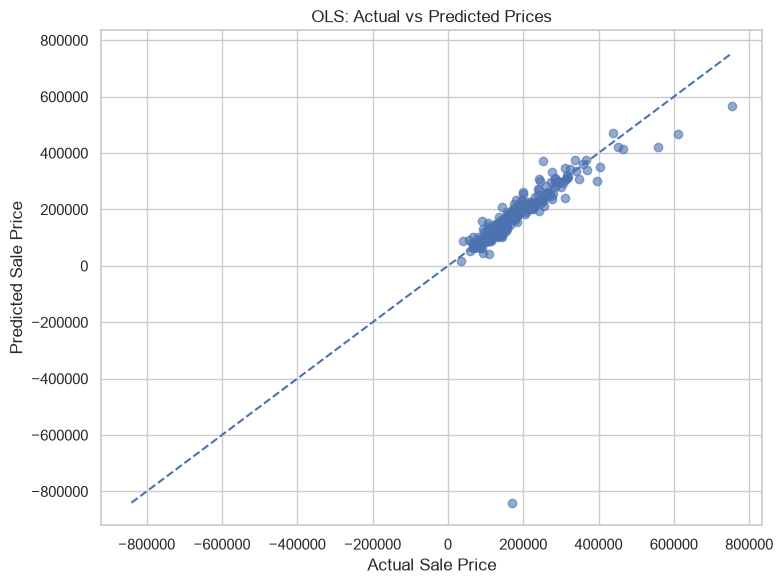

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    y_val_pred,
    alpha=0.6
)

min_value = min(y_val.min(), y_val_pred.min())
max_value = max(y_val.max(), y_val_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("OLS: Actual vs Predicted Prices")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "ols_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
residuals = y_val - y_val_pred

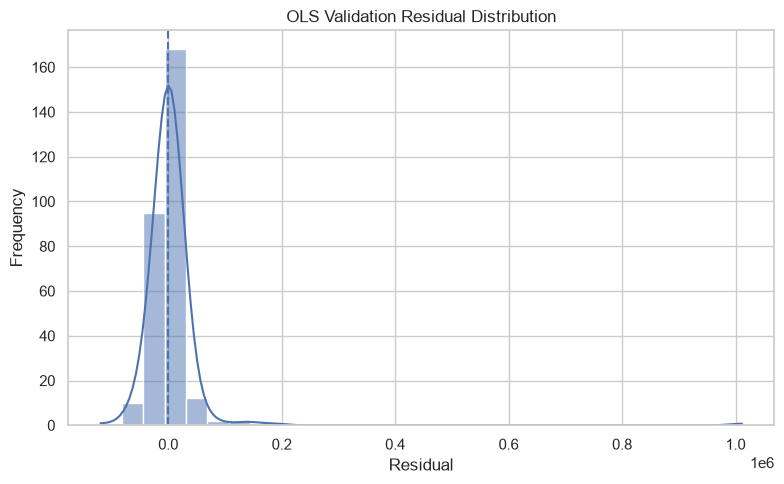

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("OLS Validation Residual Distribution")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "ols_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

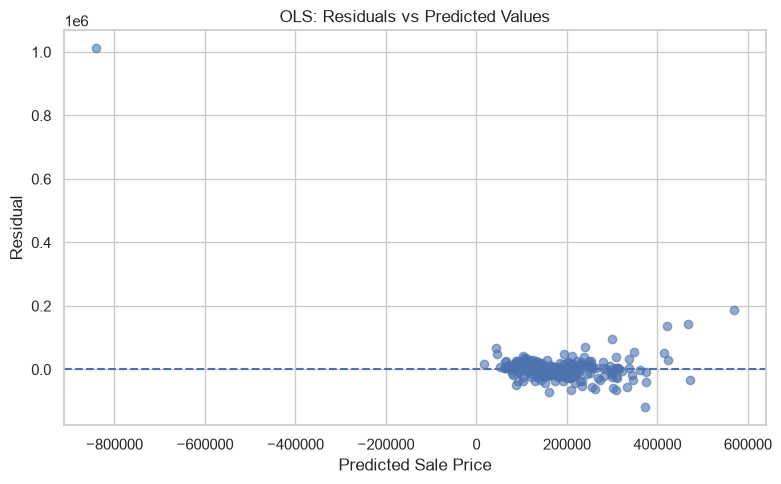

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_val_pred,
    residuals,
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")
plt.title("OLS: Residuals vs Predicted Values")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "ols_residuals_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
coefficients_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ols_model.coef_
})

coefficients_df["Absolute_Coefficient"] = coefficients_df["Coefficient"].abs()

coefficients_df = coefficients_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients_df.head(20)

,Feature,Coefficient,Absolute_Coefficient
275,PoolQC_Missing,3.001877e+06,3.001877e+06
274,PoolQC_Gd,-1.631735e+06,1.631735e+06
273,PoolQC_Fa,-1.087648e+06,1.087648e+06
125,RoofMatl_ClyTile,8.123809e+05,8.123809e+05
285,MiscFeature_TenC,6.145746e+05,6.145746e+05
272,PoolQC_Ex,-2.824938e+05,2.824938e+05
32,PoolArea,2.644733e+05,2.644733e+05
102,Condition2_PosN,-1.954023e+05,1.954023e+05
281,MiscFeature_Gar2,-1.745577e+05,1.745577e+05
284,MiscFeature_Shed,-1.495256e+05,1.495256e+05


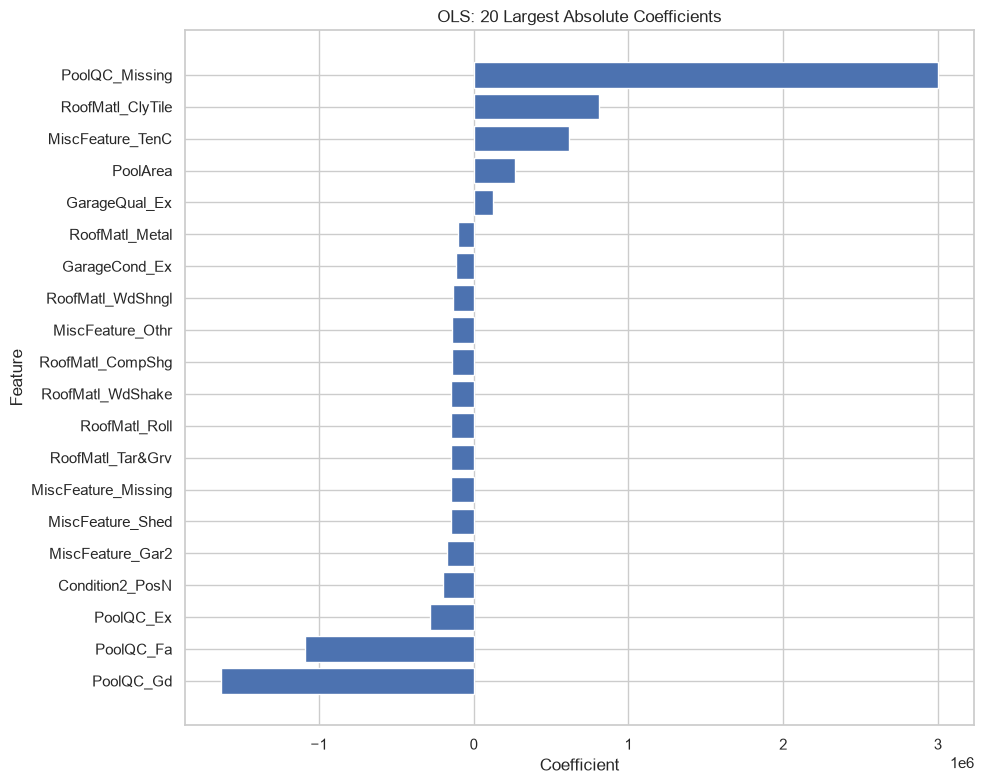

In [19]:
top_coefficients = coefficients_df.head(20).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("OLS: 20 Largest Absolute Coefficients")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "ols_top_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
ols_results.to_csv(EXPERIMENTS_DIR / "ols_baseline_metrics.csv")

print("OLS baseline metrics saved")

OLS baseline metrics saved


In [21]:
ols_predictions = pd.DataFrame({
    "Actual": y_val,
    "Predicted": y_val_pred,
    "Residual": residuals
})

ols_predictions.to_csv(
    EXPERIMENTS_DIR / "ols_validation_predictions.csv",
    index=False
)

print("OLS validation predictions saved")

OLS validation predictions saved


In [22]:
print("OLS BASELINE SUMMARY")
print("-" * 40)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

print("\nValidation Metrics")

for metric, value in val_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nIntercept:", ols_model.intercept_)

OLS BASELINE SUMMARY
----------------------------------------
Training samples: 1168
Validation samples: 292
Number of features: 301

Validation Metrics
MAE: 21125.4500
MSE: 4275239669.1940
RMSE: 65385.3169
R2: 0.4426

Intercept: -2578024.988122625


## Conclusion

In this notebook, an Ordinary Least Squares (OLS) Linear Regression model was trained using scikit-learn on the preprocessed Ames Housing dataset.

The model was evaluated using MAE, MSE, RMSE, and R² on both training and validation datasets. Actual-versus-predicted plots and residual analysis were used to examine prediction errors and model behavior.

The resulting validation metrics establish the baseline performance for the optimization experiments.

In the next stage, Batch Gradient Descent will be implemented from scratch using NumPy. Its performance will be compared against this OLS baseline using the same train-validation split, preprocessing pipeline, and evaluation metrics.

**Key outcome:** A reproducible OLS reference has been established for evaluating custom gradient descent algorithms.